In [ ]:
!nvidia-smi

Wed Aug 13 09:22:43 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   59C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

Mounted at /content/drive


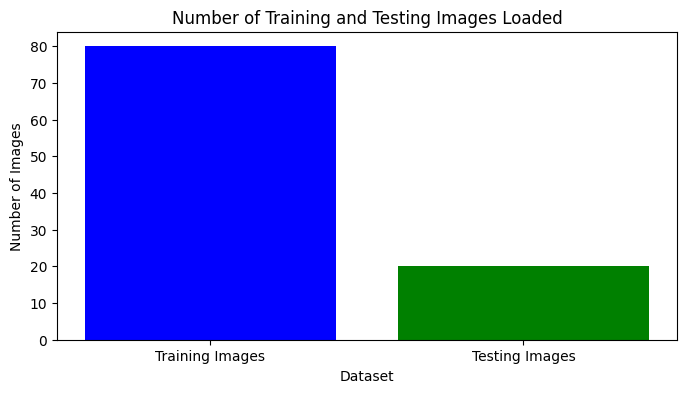

Number of training images loaded: 80
Number of testing images loaded: 20

Total number of images loaded: 100
Images that couldn't be loaded:
Training images: []
Testing images: []


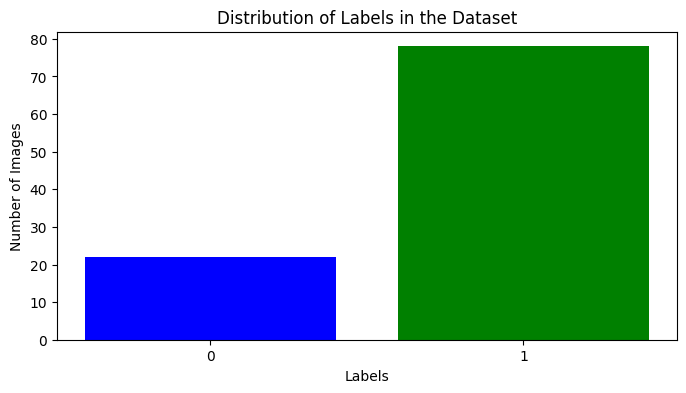

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 93s 16s/step - accuracy: 0.6263 - loss: 0.2590 - val_accuracy: 0.2500 - val_loss: -52.1245


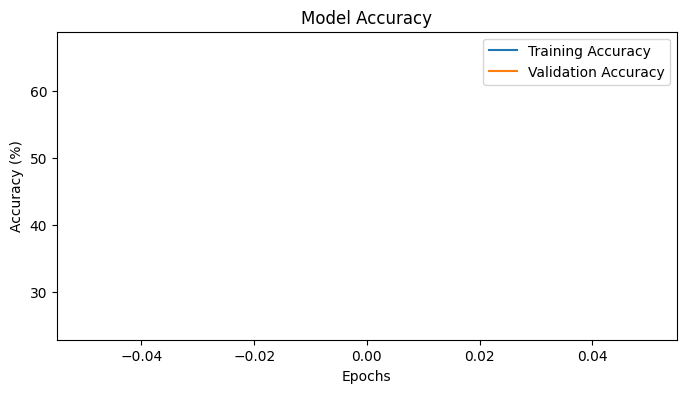

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.5500 - loss: -16.6997
Testing Accuracy: 0.550000011920929


Saving 1ffa92f3-8d87-11e8-9daf-6045cb817f5b..JPG to 1ffa92f3-8d87-11e8-9daf-6045cb817f5b..JPG
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
Diabetic Retinopathy Positive
Diabetic Retinopathy Severity: Severe


In [ ]:
import numpy as np
import pandas as pd
import os
import cv2
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import pickle
import gzip
import sys
from google.colab import files
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

train_data = pd.read_csv('/content/drive/My Drive/Plot/Train.csv')

# Ensure filenames are strings and drop rows with NaN filenames
train_data['filename'] = train_data['filename'].astype(str)
train_data = train_data[train_data['filename'] != 'nan']

# Split the dataset into training and testing sets
train_images, test_images, train_labels, test_labels = train_test_split(train_data['filename'], train_data[['label', 'severity']], test_size=0.2, random_state=42)

# Function to load and preprocess images
def load_images(filenames, base_path):
    images = []
    failed_to_load = []
    for filename in filenames:
        img_path = os.path.join(base_path, filename)
        try:
            img = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)
            if img is not None:
                if img.shape[2] == 4:
                    img = cv2.cvtColor(img, cv2.COLOR_BGRA2RGB)
                img = cv2.resize(img, (224, 224))
                images.append(img)
            else:
                failed_to_load.append(filename)
        except Exception as e:
            failed_to_load.append(filename)
    return np.array(images), failed_to_load

# Load and preprocess training images
train_images, failed_to_load = load_images(train_images, '/content/drive/My Drive/Plot')

# Load and preprocess testing images
test_images, failed_to_load_test = load_images(test_images, '/content/drive/My Drive/Plot')

# Plot number of training and testing images loaded
plt.figure(figsize=(8, 4))
plt.bar(['Training Images', 'Testing Images'], [len(train_images), len(test_images)], color=['blue', 'green'])
plt.xlabel('Dataset')
plt.ylabel('Number of Images')
plt.title('Number of Training and Testing Images Loaded')
plt.show()

# Print number of training images loaded
print("Number of training images loaded:", len(train_images))

# Print number of testing images loaded
print("Number of testing images loaded:", len(test_images))

# Print total number of images loaded
print("\nTotal number of images loaded:", len(train_images) + len(test_images))

# Print list of images that couldn't be loaded
print("Images that couldn't be loaded:")
print("Training images:", failed_to_load)
print("Testing images:", failed_to_load_test)

# Assuming `train_labels` and `test_labels` contain a column named 'label' that includes the labels.
# You need to extract the 'label' column from each if they're structured with multiple labels or details.
if 'label' in train_labels.columns:
    all_labels = np.concatenate([train_labels['label'], test_labels['label']])
else:
    all_labels = np.concatenate([train_labels[:, 0], test_labels[:, 0]])  # Adjust indexing if necessary

# Count the occurrences of each label (0 and 1)
labels, counts = np.unique(all_labels, return_counts=True)

# Plotting the bar graph
plt.figure(figsize=(8, 4))
plt.bar(labels, counts, color=['blue', 'green'])
plt.xlabel('Labels')
plt.ylabel('Number of Images')
plt.title('Distribution of Labels in the Dataset')
plt.xticks(labels, [str(label) for label in labels])  # Set x-ticks to be explicit labels
plt.show()

# Load pre-trained ResNet50 model
base_model = ResNet50(input_shape=(224, 224, 3), weights='imagenet', include_top=False)

# Build your model architecture on top of ResNet50
x = base_model.output
x = Flatten()(x)
x = Dropout(0.5)(x)
x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)
predictions = Dense(2, activation='sigmoid')(x)

# Create the final model
model = Model(inputs=base_model.input, outputs=predictions)

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model and store training history
history = model.fit(train_images, train_labels, batch_size=32, epochs=1, validation_split=0.1)
# Plot training and validation accuracy
plt.figure(figsize=(8, 4))
plt.plot(np.array(history.history['accuracy']) * 100, label='Training Accuracy')
plt.plot(np.array(history.history['val_accuracy']) * 100, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.title('Model Accuracy')
plt.legend()
plt.show()


# Evaluate the model on the testing data
loss, accuracy = model.evaluate(test_images, test_labels)
print("Testing Accuracy:", accuracy)

# Save the model weights and architecture separately and compress them using gzip
model.save_weights('/content/drive/My Drive/Requirements/model_weights.weights.h5')  # Changed extension to .weights.h5

with open('/content/drive/My Drive/Requirements/model_architecture.json', 'w') as f:
    f.write(model.to_json())

# Compress model weights file
with open('/content/drive/My Drive/Requirements/model_weights.weights.h5', 'rb') as f_in, gzip.open('/content/drive/My Drive/Requirements/model_weights.weights.h5.gz', 'wb') as f_out:
    f_out.writelines(f_in)

# Compress model architecture file
with open('/content/drive/My Drive/Requirements/model_architecture.json', 'rb') as f_in, gzip.open('/content/drive/My Drive/Requirements/model_architecture.json.gz', 'wb') as f_out:
    f_out.writelines(f_in)


# Upload a new image for testing
uploaded_files = files.upload()
uploaded_image_path = list(uploaded_files.keys())[0]
new_image = cv2.imread(uploaded_image_path, cv2.IMREAD_UNCHANGED)

# Remove alpha channel if present
if new_image.shape[2] == 4:
    new_image = new_image[:, :, :3]

# Preprocess the new image
def preprocess_image(img):
    if img.shape[2] == 4:
        img = cv2.cvtColor(img, cv2.COLOR_RGBA2RGB)
    img = cv2.resize(img, (224, 224))
    return img

if new_image is not None:
    new_image = preprocess_image(new_image)
    new_image = np.expand_dims(new_image, axis=0)
    prediction = model.predict(new_image)
    if prediction[0][0] > 0.5:
        print("Diabetic Retinopathy Positive")
        severity_prediction = prediction[0][1]
        severity = None
        if severity_prediction <= 1/3:
            severity = "Mild"
        elif severity_prediction <= 2/3:
            severity = "Moderate"
        else:
            severity = "Severe"
        print("Diabetic Retinopathy Severity:", severity)
    else:
        print("Diabetic Retinopathy Negative")
        severity = "None"
else:
    print("Failed to load image.")


Mounted at /content/drive
Found 7474 images belonging to 2 classes.
Found 1867 images belonging to 2 classes.
Class indices: {'Negative': 0, 'Positive': 1}


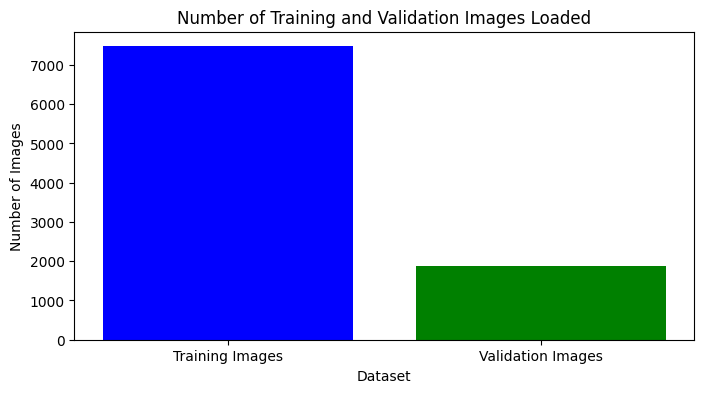

Category Counts: {'Negative': 2493, 'Positive': 6848}
Severity Counts: {'Mild': 2312, 'Moderate': 2847, 'Severe': 1689}


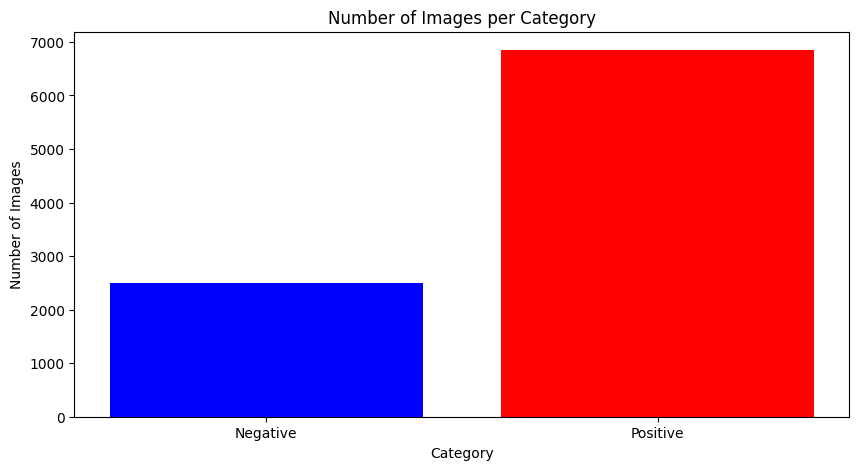

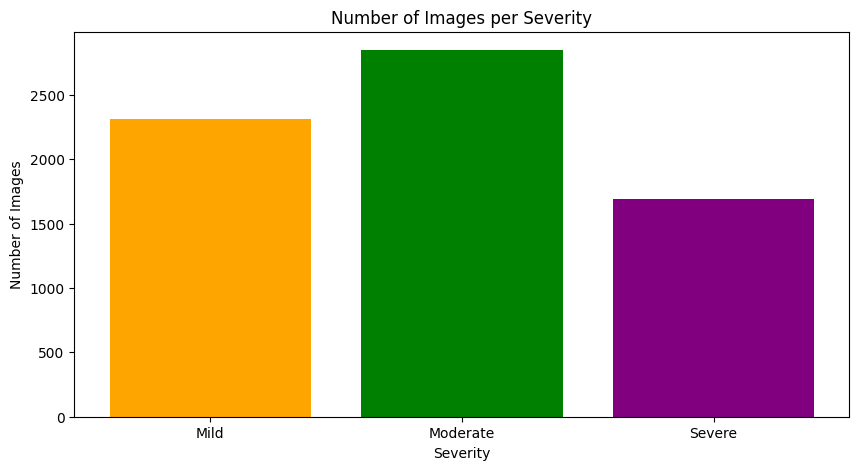

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/2
219/234 ━━━━━━━━━━━━━━━━━━━━ 3:21 13s/step - accuracy: 0.9231 - loss: 0.2665

In [ ]:
import numpy as np
import os
import cv2
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils import class_weight
from sklearn.metrics import confusion_matrix
from google.colab import files
from google.colab import drive
from tensorflow.keras.callbacks import EarlyStopping

# Mount Google Drive
drive.mount('/content/drive')

# Define paths for the dataset
base_dir = '/content/drive/My Drive/small/'

# Create ImageDataGenerators for training and validation data with augmentation
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    # Data augmentation
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Load data from the base directory
train_generator = datagen.flow_from_directory(
    directory=base_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

validation_generator = datagen.flow_from_directory(
    directory=base_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

# Print class indices to verify they match expected names
print("Class indices:", train_generator.class_indices)

# Plot number of training and validation images loaded
plt.figure(figsize=(8, 4))
plt.bar(['Training Images', 'Validation Images'], [train_generator.samples, validation_generator.samples], color=['blue', 'green'])
plt.xlabel('Dataset')
plt.ylabel('Number of Images')
plt.title('Number of Training and Validation Images Loaded')
plt.show()

# Count images per category and severity directly from directory
def count_images_in_directory(base_path):
    category_counts = {}
    severity_counts = {}

    # List of categories and severity levels
    categories = ['Negative', 'Positive']
    severities = ['Mild', 'Moderate', 'Severe']

    # Count images in each category
    for category in categories:
        category_path = os.path.join(base_path, category)
        if os.path.isdir(category_path):
            count = sum([len(files) for r, d, files in os.walk(category_path)])
            category_counts[category] = count

    # Count images in each severity level within 'Positive'
    positive_path = os.path.join(base_path, 'Positive')
    if os.path.isdir(positive_path):
        for severity in severities:
            severity_path = os.path.join(positive_path, severity)
            if os.path.isdir(severity_path):
                count = len(os.listdir(severity_path))
                severity_counts[severity] = count

        # Summing severity counts to get total for 'Positive'
        category_counts['Positive'] = sum(severity_counts.values())

    return category_counts, severity_counts

category_counts, severity_counts = count_images_in_directory(base_dir)

# Print counts
print("Category Counts:", category_counts)
print("Severity Counts:", severity_counts)

# Plot counts for categories
plt.figure(figsize=(10, 5))
plt.bar(category_counts.keys(), category_counts.values(), color=['blue', 'red'])
plt.xlabel('Category')
plt.ylabel('Number of Images')
plt.title('Number of Images per Category')
plt.show()

# Plot counts for severity
plt.figure(figsize=(10, 5))
plt.bar(severity_counts.keys(), severity_counts.values(), color=['orange', 'green', 'purple'])
plt.xlabel('Severity')
plt.ylabel('Number of Images')
plt.title('Number of Images per Severity')
plt.show()

# Build model for category classification
base_model = ResNet50(input_shape=(224, 224, 3), weights='imagenet', include_top=False)

x = base_model.output
x = Flatten()(x)
x = Dropout(0.3)(x)  # Adjust dropout rate
x = Dense(128, activation='relu')(x)  # Reduce number of units
x = BatchNormalization()(x)
predictions = Dense(train_generator.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Calculate class weights
class_weights = class_weight.compute_class_weight(
    'balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
class_weights_dict = dict(enumerate(class_weights))

# Define early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the category model
history = model.fit(
    train_generator,
    epochs=2,  # Increase epochs if needed
    validation_data=validation_generator,
    callbacks=[early_stopping],
    class_weight=class_weights_dict
)

# Plot training and validation accuracy
plt.figure(figsize=(8, 4))
plt.plot(np.array(history.history['accuracy']) * 100, label='Training Accuracy')
plt.plot(np.array(history.history['val_accuracy']) * 100, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.title('Model Accuracy')
plt.legend()
plt.show()

# Evaluate the model on the validation data
loss, accuracy = model.evaluate(validation_generator)
print("Validation Accuracy:", accuracy)

# Save the model weights and architecture separately and compress them using gzip
import gzip

model.save_weights('/content/drive/My Drive/Requirements/model_weights.weights.h5')

with open('/content/drive/My Drive/Requirements/model_architecture.json', 'w') as f:
    f.write(model.to_json())

# Compress model weights file
with open('/content/drive/My Drive/Requirements/model_weights.weights.h5', 'rb') as f_in, gzip.open('/content/drive/My Drive/Requirements/model_weights.weights.h5.gz', 'wb') as f_out:
    f_out.writelines(f_in)

# Compress model architecture file
with open('/content/drive/My Drive/Requirements/model_architecture.json', 'rb') as f_in, gzip.open('/content/drive/My Drive/Requirements/model_architecture.json.gz', 'wb') as f_out:
    f_out.writelines(f_in)

# Train a secondary model for severity classification

# Create ImageDataGenerators for severity data
severity_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

severity_train_generator = severity_datagen.flow_from_directory(
    directory=os.path.join(base_dir, 'Positive'),
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

severity_validation_generator = severity_datagen.flow_from_directory(
    directory=os.path.join(base_dir, 'Positive'),
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

# Define the severity model
base_severity_model = ResNet50(input_shape=(224, 224, 3), weights='imagenet', include_top=False)

x_severity = base_severity_model.output
x_severity = Flatten()(x_severity)
x_severity = Dropout(0.3)(x_severity)
x_severity = Dense(128, activation='relu')(x_severity)
x_severity = BatchNormalization()(x_severity)
severity_predictions = Dense(severity_train_generator.num_classes, activation='softmax')(x_severity)

severity_model = Model(inputs=base_severity_model.input, outputs=severity_predictions)

# Compile the severity model
severity_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the severity model
severity_history = severity_model.fit(
    severity_train_generator,
    epochs=30,
    validation_data=severity_validation_generator,
    callbacks=[early_stopping]
)

# Plot training and validation accuracy for severity model
plt.figure(figsize=(8, 4))
plt.plot(np.array(severity_history.history['accuracy']) * 100, label='Training Accuracy')
plt.plot(np.array(severity_history.history['val_accuracy']) * 100, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.title('Severity Model Accuracy')
plt.legend()
plt.show()

# Evaluate the severity model
severity_loss, severity_accuracy = severity_model.evaluate(severity_validation_generator)
print("Severity Validation Accuracy:", severity_accuracy)

# Function to preprocess and classify an image
def classify_image(img_path):
    img = preprocess_image(img_path)
    img = np.expand_dims(img, axis=0)

    # First classification
    initial_prediction = model.predict(img)
    initial_class = np.argmax(initial_prediction, axis=1)
    class_labels = list(train_generator.class_indices.keys())

    if class_labels[initial_class[0]] == 'Positive':
        # If Positive, classify severity
        severity_prediction = severity_model.predict(img)
        severity_class = np.argmax(severity_prediction, axis=1)
        severity_labels = list(severity_train_generator.class_indices.keys())
        return f"Class: Positive, Severity: {severity_labels[severity_class[0]]}"
    else:
        return f"Class: {class_labels[initial_class[0]]}"

# Upload a new image for testing
uploaded_files = files.upload()
uploaded_image_path = list(uploaded_files.keys())[0]

# Process the uploaded image
try:
    result = classify_image(uploaded_image_path)
    print(f"Prediction Result: {result}")
except Exception as e:
    print(f"Error: {e}")

# Confusion matrix for validation predictions
validation_generator.reset()
predictions = model.predict(validation_generator, steps=validation_generator.samples // validation_generator.batch_size + 1)
predicted_classes = np.argmax(predictions, axis=1)

# Confusion matrix
cm = confusion_matrix(validation_generator.classes, predicted_classes)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=train_generator.class_indices.keys(), yticklabels=train_generator.class_indices.keys())
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


In [ ]:
# ============================
# 0) Imports & setup
# ============================
import os, json, numpy as np, matplotlib.pyplot as plt, seaborn as sns
import tensorflow as tf

from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report

from google.colab import drive, files

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

# Optional GPU check (skip if it errors)
try:
    import subprocess
    print(subprocess.check_output(["nvidia-smi"]).decode())
except Exception as e:
    print("GPU check skipped or not available:", e)

# ============================
# 1) Mount Drive & paths
# ============================
drive.mount('/content/drive')

# >>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
# CHANGE THIS to your local *fast* dataset (recommended under /content/)
# Expected structure:
# /content/dataset/
#   ├── Negative/
#   └── Positive/
#         ├── Mild/
#         ├── Moderate/
#         └── Severe/
# <<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<
DATA_ROOT = '/content/drive/My Drive/small/'

STAGE1_DIR = DATA_ROOT                                  # Negative vs Positive
STAGE2_DIR = os.path.join(DATA_ROOT, "Positive")         # Mild/Moderate/Severe

SAVE_DIR  = "/content/drive/My Drive/Requirements"
os.makedirs(SAVE_DIR, exist_ok=True)

IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
VAL_SPLIT  = 0.2

# ============================
# 2) Generators (with proper ResNet50 preprocessing)
# ============================
augment_args = dict(
    preprocessing_function=preprocess_input,  # <-- important
    validation_split=VAL_SPLIT,
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.15,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Stage 1 (Negative/Positive)
stage1_datagen = ImageDataGenerator(**augment_args)

stage1_train = stage1_datagen.flow_from_directory(
    directory=STAGE1_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=SEED
)

stage1_val = stage1_datagen.flow_from_directory(
    directory=STAGE1_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=SEED,
    shuffle=False
)

print("Stage-1 class indices:", stage1_train.class_indices)

# Stage 2 (Mild/Moderate/Severe under Positive)
stage2_datagen = ImageDataGenerator(**augment_args)

stage2_train = stage2_datagen.flow_from_directory(
    directory=STAGE2_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=SEED
)

stage2_val = stage2_datagen.flow_from_directory(
    directory=STAGE2_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=SEED,
    shuffle=False
)

print("Stage-2 class indices:", stage2_train.class_indices)

# ============================
# 3) Utilities
# ============================
def plot_history(history, title_prefix=""):
    plt.figure(figsize=(12,4))
    # Accuracy
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label='train')
    plt.plot(history.history['val_accuracy'], label='val')
    plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.title(f'{title_prefix} Accuracy'); plt.legend()
    # Loss
    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='train')
    plt.plot(history.history['val_loss'], label='val')
    plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title(f'{title_prefix} Loss'); plt.legend()
    plt.show()

def compute_weights_from_generator(gen):
    classes = np.unique(gen.classes)
    weights = compute_class_weight(class_weight='balanced', classes=classes, y=gen.classes)
    return {int(c): float(w) for c, w in zip(classes, weights)}

stage1_class_weights = compute_weights_from_generator(stage1_train)
stage2_class_weights = compute_weights_from_generator(stage2_train)
print("Stage-1 class weights:", stage1_class_weights)
print("Stage-2 class weights:", stage2_class_weights)

# ============================
# 4) Model builder (Keras 3 compatible)
# ============================
def build_resnet50_classifier(num_classes, train_base=False):
    base = ResNet50(include_top=False, weights='imagenet', input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
    base.trainable = train_base  # start frozen
    x = base.output
    x = GlobalAveragePooling2D()(x)         # <-- fewer params than Flatten
    x = Dropout(0.3)(x)
    x = Dense(256, activation='relu')(x)    # <-- CALL the layer on the tensor
    x = BatchNormalization()(x)
    outputs = Dense(num_classes, activation='softmax')(x)
    model = Model(base.input, outputs)
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model, base

# ============================
# 5) Stage 1 training (Neg/Pos)
# ============================
stage1_model, stage1_base = build_resnet50_classifier(stage1_train.num_classes, train_base=False)

stage1_ckpt_path = os.path.join(SAVE_DIR, "stage1_best.keras")
stage1_callbacks = [
    ModelCheckpoint(stage1_ckpt_path, monitor='val_accuracy', mode='max', save_best_only=True, verbose=1),
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6, verbose=1)
]

print("\n[Stage 1] Train head (frozen base)...")
history1_head = stage1_model.fit(
    stage1_train,
    validation_data=stage1_val,
    epochs=10,
    class_weight=stage1_class_weights,
    callbacks=stage1_callbacks,
    verbose=1
)
plot_history(history1_head, "Stage-1 (Frozen)")

print("\n[Stage 1] Fine-tune (unfreeze last ~50 layers)...")
stage1_base.trainable = True
for layer in stage1_base.layers[:-50]:
    layer.trainable = False

stage1_model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
                     loss='categorical_crossentropy',
                     metrics=['accuracy'])

history1_ft = stage1_model.fit(
    stage1_train,
    validation_data=stage1_val,
    epochs=10,
    class_weight=stage1_class_weights,
    callbacks=stage1_callbacks,
    verbose=1
)
plot_history(history1_ft, "Stage-1 (Fine-tune)")

# Evaluate & CM
print("\n[Stage 1] Validation evaluation:")
stage1_val.reset()
s1_loss, s1_acc = stage1_model.evaluate(stage1_val, verbose=0)
print(f"Stage-1 Val Acc: {s1_acc:.4f}")

stage1_val.reset()
s1_pred = stage1_model.predict(stage1_val, verbose=0)
y1_true = stage1_val.classes
y1_pred = np.argmax(s1_pred, axis=1)

cm1 = confusion_matrix(y1_true, y1_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm1, annot=True, fmt='d',
            xticklabels=list(stage1_train.class_indices.keys()),
            yticklabels=list(stage1_train.class_indices.keys()))
plt.title("Stage-1 Confusion Matrix")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.show()

print("\nStage-1 Classification Report:\n",
      classification_report(y1_true, y1_pred, target_names=list(stage1_train.class_indices.keys())))

stage1_model.save(os.path.join(SAVE_DIR, "stage1_model.keras"))
print("Saved:", os.path.join(SAVE_DIR, "stage1_model.keras"))

# ============================
# 6) Stage 2 training (Mild/Moderate/Severe)
# ============================
stage2_model, stage2_base = build_resnet50_classifier(stage2_train.num_classes, train_base=False)

stage2_ckpt_path = os.path.join(SAVE_DIR, "stage2_best.keras")
stage2_callbacks = [
    ModelCheckpoint(stage2_ckpt_path, monitor='val_accuracy', mode='max', save_best_only=True, verbose=1),
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6, verbose=1)
]

print("\n[Stage 2] Train head (frozen base)...")
history2_head = stage2_model.fit(
    stage2_train,
    validation_data=stage2_val,
    epochs=15,
    class_weight=stage2_class_weights,
    callbacks=stage2_callbacks,
    verbose=1
)
plot_history(history2_head, "Stage-2 (Frozen)")

print("\n[Stage 2] Fine-tune (unfreeze last ~50 layers)...")
stage2_base.trainable = True
for layer in stage2_base.layers[:-50]:
    layer.trainable = False

stage2_model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
                     loss='categorical_crossentropy',
                     metrics=['accuracy'])

history2_ft = stage2_model.fit(
    stage2_train,
    validation_data=stage2_val,
    epochs=15,
    class_weight=stage2_class_weights,
    callbacks=stage2_callbacks,
    verbose=1
)
plot_history(history2_ft, "Stage-2 (Fine-tune)")

# Evaluate & CM
print("\n[Stage 2] Validation evaluation:")
stage2_val.reset()
s2_loss, s2_acc = stage2_model.evaluate(stage2_val, verbose=0)
print(f"Stage-2 Val Acc: {s2_acc:.4f}")

stage2_val.reset()
s2_pred = stage2_model.predict(stage2_val, verbose=0)
y2_true = stage2_val.classes
y2_pred = np.argmax(s2_pred, axis=1)

cm2 = confusion_matrix(y2_true, y2_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm2, annot=True, fmt='d',
            xticklabels=list(stage2_train.class_indices.keys()),
            yticklabels=list(stage2_train.class_indices.keys()))
plt.title("Stage-2 Confusion Matrix")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.show()

print("\nStage-2 Classification Report:\n",
      classification_report(y2_true, y2_pred, target_names=list(stage2_train.class_indices.keys())))

stage2_model.save(os.path.join(SAVE_DIR, "stage2_model.keras"))
print("Saved:", os.path.join(SAVE_DIR, "stage2_model.keras"))

# ============================
# 7) Inference: end-to-end on a single image
# ============================
from tensorflow.keras.preprocessing.image import img_to_array, load_img

# Load best checkpoints
stage1_model = tf.keras.models.load_model(stage1_ckpt_path)
stage2_model = tf.keras.models.load_model(stage2_ckpt_path)

stage1_labels = {v:k for k,v in stage1_train.class_indices.items()}
stage2_labels = {v:k for k,v in stage2_train.class_indices.items()}

def load_and_preprocess(path):
    img = load_img(path, target_size=IMG_SIZE)    # RGB PIL
    arr = img_to_array(img)
    arr = np.expand_dims(arr, axis=0)
    arr = preprocess_input(arr)                   # same as training
    return arr

def predict_image(path, pos_threshold=0.5):
    x = load_and_preprocess(path)
    p1 = stage1_model.predict(x, verbose=0)[0]
    c1 = int(np.argmax(p1))
    conf1 = float(p1[c1])
    name1 = stage1_labels[c1]

    result = {
        "stage1": {"label": name1, "probs": {stage1_labels[i]: float(p1[i]) for i in range(len(p1))}},
        "stage2": None
    }

    if name1.lower() == "positive" and conf1 >= pos_threshold:
        p2 = stage2_model.predict(x, verbose=0)[0]
        c2 = int(np.argmax(p2))
        result["stage2"] = {"label": stage2_labels[c2],
                            "probs": {stage2_labels[i]: float(p2[i]) for i in range(len(p2))}}
    return result

print("\nUpload an image to test:")
up = files.upload()
test_path = list(up.keys())[0]
print(json.dumps(predict_image(test_path), indent=2))


Tue Aug 19 07:55:06 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   58C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


234/234 ━━━━━━━━━━━━━━━━━━━━ 0s 12s/step - accuracy: 0.9501 - loss: 0.1584 
Epoch 1: val_accuracy improved from -inf to 0.98500, saving model to /content/drive/My Drive/Requirements/stage1_best.keras
234/234 ━━━━━━━━━━━━━━━━━━━━ 3699s 16s/step - accuracy: 0.9502 - loss: 0.1581 - val_accuracy: 0.9850 - val_loss: 0.0782 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 1.


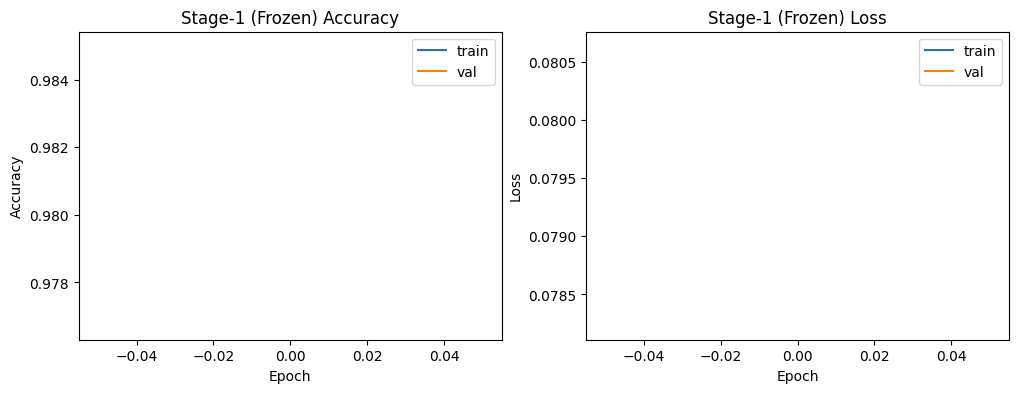


[Stage 1] Fine-tune (unfreeze last ~50 layers)...
234/234 ━━━━━━━━━━━━━━━━━━━━ 0s 717ms/step - accuracy: 0.9869 - loss: 0.0335
Epoch 1: val_accuracy did not improve from 0.98500
234/234 ━━━━━━━━━━━━━━━━━━━━ 249s 950ms/step - accuracy: 0.9869 - loss: 0.0335 - val_accuracy: 0.9754 - val_loss: 0.2191 - learning_rate: 1.0000e-04
Restoring model weights from the end of the best epoch: 1.


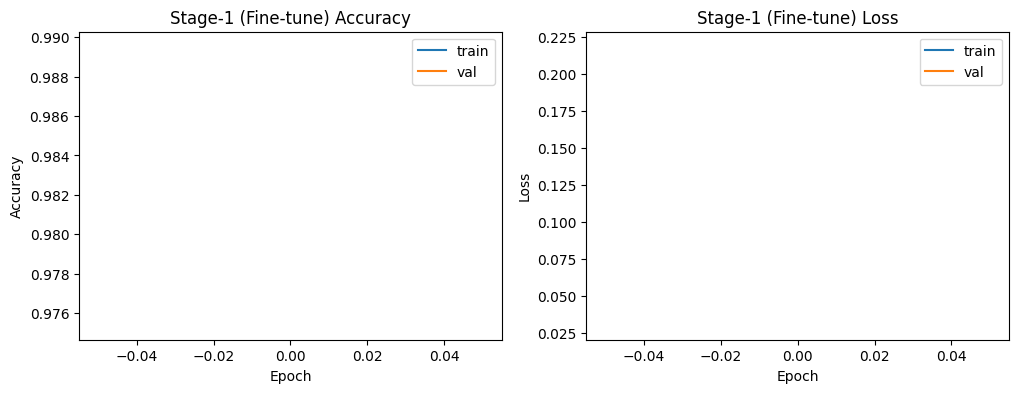


[Stage 1] Validation evaluation:
Stage-1 Val Acc: 0.9780


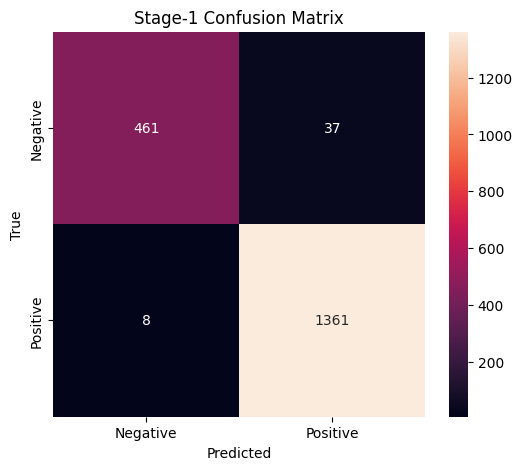


Stage-1 Classification Report:
               precision    recall  f1-score   support

    Negative       0.98      0.93      0.95       498
    Positive       0.97      0.99      0.98      1369

    accuracy                           0.98      1867
   macro avg       0.98      0.96      0.97      1867
weighted avg       0.98      0.98      0.98      1867

Saved: /content/drive/My Drive/Requirements/stage1_model.keras

[Stage 2] Train head (frozen base)...


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


172/172 ━━━━━━━━━━━━━━━━━━━━ 0s 651ms/step - accuracy: 0.4790 - loss: 1.1733
Epoch 1: val_accuracy improved from -inf to 0.55409, saving model to /content/drive/My Drive/Requirements/stage2_best.keras
172/172 ━━━━━━━━━━━━━━━━━━━━ 185s 980ms/step - accuracy: 0.4793 - loss: 1.1724 - val_accuracy: 0.5541 - val_loss: 0.9093 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 1.


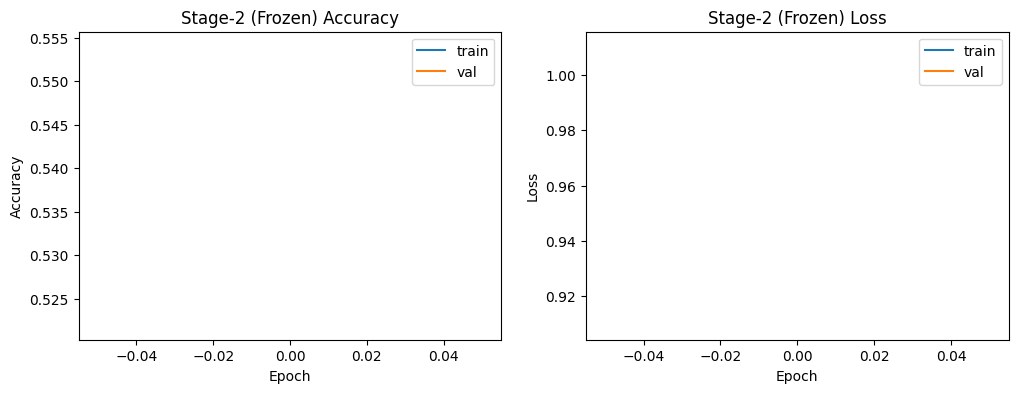


[Stage 2] Fine-tune (unfreeze last ~50 layers)...
172/172 ━━━━━━━━━━━━━━━━━━━━ 0s 709ms/step - accuracy: 0.5712 - loss: 0.8464
Epoch 1: val_accuracy improved from 0.55409 to 0.62646, saving model to /content/drive/My Drive/Requirements/stage2_best.keras
172/172 ━━━━━━━━━━━━━━━━━━━━ 185s 928ms/step - accuracy: 0.5714 - loss: 0.8458 - val_accuracy: 0.6265 - val_loss: 0.8280 - learning_rate: 1.0000e-04
Restoring model weights from the end of the best epoch: 1.


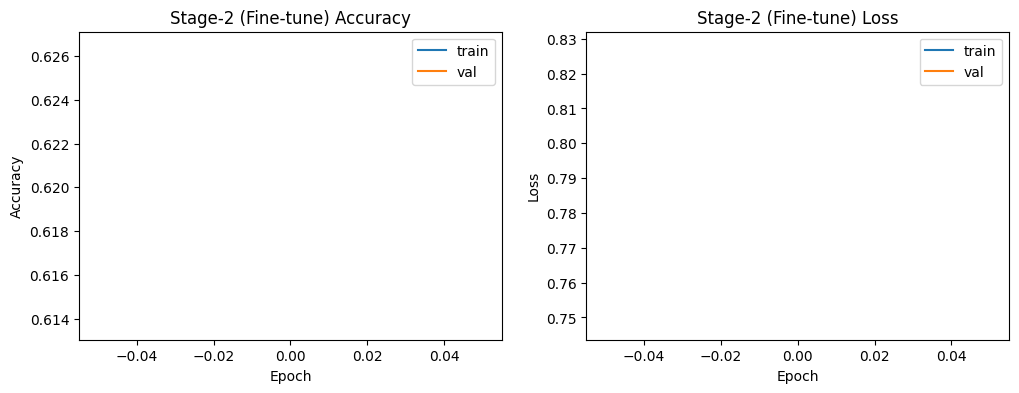


[Stage 2] Validation evaluation:
Stage-2 Val Acc: 0.6265


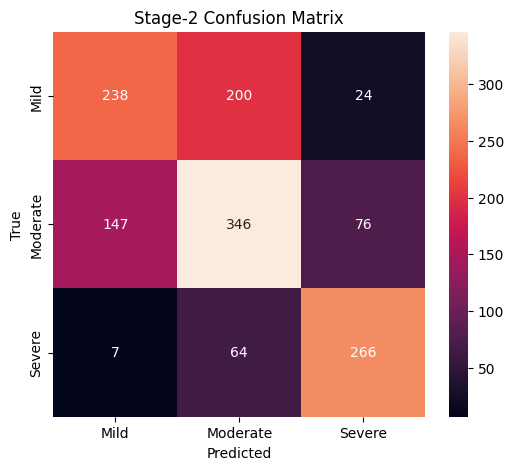


Stage-2 Classification Report:
               precision    recall  f1-score   support

        Mild       0.61      0.52      0.56       462
    Moderate       0.57      0.61      0.59       569
      Severe       0.73      0.79      0.76       337

    accuracy                           0.62      1368
   macro avg       0.63      0.64      0.63      1368
weighted avg       0.62      0.62      0.62      1368

Saved: /content/drive/My Drive/Requirements/stage2_model.keras

Upload an image to test:


Saving 51_43_M_OD.jpg to 51_43_M_OD.jpg
{
  "stage1": {
    "label": "Negative",
    "probs": {
      "Negative": 0.9988835453987122,
      "Positive": 0.0011164693860337138
    }
  },
  "stage2": null
}


In [ ]:
# ============================
# 0) Imports & setup
# ============================
import os, json, numpy as np, matplotlib.pyplot as plt, seaborn as sns
import tensorflow as tf

from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report

from google.colab import drive, files

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

# Optional GPU check (skip if it errors)
try:
    import subprocess
    print(subprocess.check_output(["nvidia-smi"]).decode())
except Exception as e:
    print("GPU check skipped or not available:", e)

# ============================
# 1) Mount Drive & paths
# ============================
drive.mount('/content/drive')

# >>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
# CHANGE THIS to your local *fast* dataset (recommended under /content/)
# Expected structure:
# /content/dataset/
#   ├── Negative/
#   └── Positive/
#         ├── Mild/
#         ├── Moderate/
#         └── Severe/
# <<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<
DATA_ROOT = '/content/drive/My Drive/small/'

STAGE1_DIR = DATA_ROOT                                  # Negative vs Positive
STAGE2_DIR = os.path.join(DATA_ROOT, "Positive")         # Mild/Moderate/Severe

SAVE_DIR  = "/content/drive/My Drive/Requirements"
os.makedirs(SAVE_DIR, exist_ok=True)

IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
VAL_SPLIT  = 0.2

# ============================
# 2) Generators (with proper ResNet50 preprocessing)
# ============================
augment_args = dict(
    preprocessing_function=preprocess_input,  # <-- important
    validation_split=VAL_SPLIT,
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.15,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Stage 1 (Negative/Positive)
stage1_datagen = ImageDataGenerator(**augment_args)

stage1_train = stage1_datagen.flow_from_directory(
    directory=STAGE1_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=SEED
)

stage1_val = stage1_datagen.flow_from_directory(
    directory=STAGE1_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=SEED,
    shuffle=False
)

print("Stage-1 class indices:", stage1_train.class_indices)

# Stage 2 (Mild/Moderate/Severe under Positive)
stage2_datagen = ImageDataGenerator(**augment_args)

stage2_train = stage2_datagen.flow_from_directory(
    directory=STAGE2_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=SEED
)

stage2_val = stage2_datagen.flow_from_directory(
    directory=STAGE2_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=SEED,
    shuffle=False
)

print("Stage-2 class indices:", stage2_train.class_indices)

# ============================
# 3) Utilities
# ============================
def plot_history(history, title_prefix=""):
    plt.figure(figsize=(12,4))
    # Accuracy
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label='train')
    plt.plot(history.history['val_accuracy'], label='val')
    plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.title(f'{title_prefix} Accuracy'); plt.legend()
    # Loss
    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='train')
    plt.plot(history.history['val_loss'], label='val')
    plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title(f'{title_prefix} Loss'); plt.legend()
    plt.show()

def compute_weights_from_generator(gen):
    classes = np.unique(gen.classes)
    weights = compute_class_weight(class_weight='balanced', classes=classes, y=gen.classes)
    return {int(c): float(w) for c, w in zip(classes, weights)}

stage1_class_weights = compute_weights_from_generator(stage1_train)
stage2_class_weights = compute_weights_from_generator(stage2_train)
print("Stage-1 class weights:", stage1_class_weights)
print("Stage-2 class weights:", stage2_class_weights)

# ============================
# 4) Model builder (Keras 3 compatible)
# ============================
def build_resnet50_classifier(num_classes, train_base=False):
    base = ResNet50(include_top=False, weights='imagenet', input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
    base.trainable = train_base  # start frozen
    x = base.output
    x = GlobalAveragePooling2D()(x)         # <-- fewer params than Flatten
    x = Dropout(0.3)(x)
    x = Dense(256, activation='relu')(x)    # <-- CALL the layer on the tensor
    x = BatchNormalization()(x)
    outputs = Dense(num_classes, activation='softmax')(x)
    model = Model(base.input, outputs)
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model, base

# ============================
# 5) Stage 1 training (Neg/Pos)
# ============================
stage1_model, stage1_base = build_resnet50_classifier(stage1_train.num_classes, train_base=False)

stage1_ckpt_path = os.path.join(SAVE_DIR, "stage1_best.keras")
stage1_callbacks = [
    ModelCheckpoint(stage1_ckpt_path, monitor='val_accuracy', mode='max', save_best_only=True, verbose=1),
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6, verbose=1)
]

print("\n[Stage 1] Train head (frozen base)...")
history1_head = stage1_model.fit(
    stage1_train,
    validation_data=stage1_val,
    epochs=1,
    class_weight=stage1_class_weights,
    callbacks=stage1_callbacks,
    verbose=1
)
plot_history(history1_head, "Stage-1 (Frozen)")

print("\n[Stage 1] Fine-tune (unfreeze last ~50 layers)...")
stage1_base.trainable = True
for layer in stage1_base.layers[:-50]:
    layer.trainable = False

stage1_model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
                     loss='categorical_crossentropy',
                     metrics=['accuracy'])

history1_ft = stage1_model.fit(
    stage1_train,
    validation_data=stage1_val,
    epochs=1,
    class_weight=stage1_class_weights,
    callbacks=stage1_callbacks,
    verbose=1
)
plot_history(history1_ft, "Stage-1 (Fine-tune)")

# Evaluate & CM
print("\n[Stage 1] Validation evaluation:")
stage1_val.reset()
s1_loss, s1_acc = stage1_model.evaluate(stage1_val, verbose=0)
print(f"Stage-1 Val Acc: {s1_acc:.4f}")

stage1_val.reset()
s1_pred = stage1_model.predict(stage1_val, verbose=0)
y1_true = stage1_val.classes
y1_pred = np.argmax(s1_pred, axis=1)

cm1 = confusion_matrix(y1_true, y1_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm1, annot=True, fmt='d',
            xticklabels=list(stage1_train.class_indices.keys()),
            yticklabels=list(stage1_train.class_indices.keys()))
plt.title("Stage-1 Confusion Matrix")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.show()

print("\nStage-1 Classification Report:\n",
      classification_report(y1_true, y1_pred, target_names=list(stage1_train.class_indices.keys())))

stage1_model.save(os.path.join(SAVE_DIR, "stage1_model.keras"))
print("Saved:", os.path.join(SAVE_DIR, "stage1_model.keras"))

# ============================
# 6) Stage 2 training (Mild/Moderate/Severe)
# ============================
stage2_model, stage2_base = build_resnet50_classifier(stage2_train.num_classes, train_base=False)

stage2_ckpt_path = os.path.join(SAVE_DIR, "stage2_best.keras")
stage2_callbacks = [
    ModelCheckpoint(stage2_ckpt_path, monitor='val_accuracy', mode='max', save_best_only=True, verbose=1),
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6, verbose=1)
]

print("\n[Stage 2] Train head (frozen base)...")
history2_head = stage2_model.fit(
    stage2_train,
    validation_data=stage2_val,
    epochs=1,
    class_weight=stage2_class_weights,
    callbacks=stage2_callbacks,
    verbose=1
)
plot_history(history2_head, "Stage-2 (Frozen)")

print("\n[Stage 2] Fine-tune (unfreeze last ~50 layers)...")
stage2_base.trainable = True
for layer in stage2_base.layers[:-50]:
    layer.trainable = False

stage2_model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
                     loss='categorical_crossentropy',
                     metrics=['accuracy'])

history2_ft = stage2_model.fit(
    stage2_train,
    validation_data=stage2_val,
    epochs=1,
    class_weight=stage2_class_weights,
    callbacks=stage2_callbacks,
    verbose=1
)
plot_history(history2_ft, "Stage-2 (Fine-tune)")

# Evaluate & CM
print("\n[Stage 2] Validation evaluation:")
stage2_val.reset()
s2_loss, s2_acc = stage2_model.evaluate(stage2_val, verbose=0)
print(f"Stage-2 Val Acc: {s2_acc:.4f}")

stage2_val.reset()
s2_pred = stage2_model.predict(stage2_val, verbose=0)
y2_true = stage2_val.classes
y2_pred = np.argmax(s2_pred, axis=1)

cm2 = confusion_matrix(y2_true, y2_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm2, annot=True, fmt='d',
            xticklabels=list(stage2_train.class_indices.keys()),
            yticklabels=list(stage2_train.class_indices.keys()))
plt.title("Stage-2 Confusion Matrix")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.show()

print("\nStage-2 Classification Report:\n",
      classification_report(y2_true, y2_pred, target_names=list(stage2_train.class_indices.keys())))

stage2_model.save(os.path.join(SAVE_DIR, "stage2_model.keras"))
print("Saved:", os.path.join(SAVE_DIR, "stage2_model.keras"))

# ============================
# 7) Inference: end-to-end on a single image
# ============================
from tensorflow.keras.preprocessing.image import img_to_array, load_img

# Load best checkpoints
stage1_model = tf.keras.models.load_model(stage1_ckpt_path)
stage2_model = tf.keras.models.load_model(stage2_ckpt_path)

stage1_labels = {v:k for k,v in stage1_train.class_indices.items()}
stage2_labels = {v:k for k,v in stage2_train.class_indices.items()}

def load_and_preprocess(path):
    img = load_img(path, target_size=IMG_SIZE)    # RGB PIL
    arr = img_to_array(img)
    arr = np.expand_dims(arr, axis=0)
    arr = preprocess_input(arr)                   # same as training
    return arr

def predict_image(path, pos_threshold=0.5):
    x = load_and_preprocess(path)
    p1 = stage1_model.predict(x, verbose=0)[0]
    c1 = int(np.argmax(p1))
    conf1 = float(p1[c1])
    name1 = stage1_labels[c1]

    result = {
        "stage1": {"label": name1, "probs": {stage1_labels[i]: float(p1[i]) for i in range(len(p1))}},
        "stage2": None
    }

    if name1.lower() == "positive" and conf1 >= pos_threshold:
        p2 = stage2_model.predict(x, verbose=0)[0]
        c2 = int(np.argmax(p2))
        result["stage2"] = {"label": stage2_labels[c2],
                            "probs": {stage2_labels[i]: float(p2[i]) for i in range(len(p2))}}
    return result

print("\nUpload an image to test:")
up = files.upload()
test_path = list(up.keys())[0]
print(json.dumps(predict_image(test_path), indent=2))


In [ ]:
# ============================
# 0) Imports & setup
# ============================
import os, json, numpy as np, matplotlib.pyplot as plt, seaborn as sns, tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report
from google.colab import drive, files

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

# Mixed precision speeds up training on T4
try:
    from tensorflow.keras import mixed_precision
    mixed_precision.set_global_policy("mixed_float16")
    print("Mixed precision enabled.")
except Exception as e:
    print("Mixed precision not enabled:", e)

# ============================
# 1) Mount Drive & paths
# ============================
drive.mount('/content/drive')

# Expected structure:
# /content/dataset/
#   ├── Negative/
#   └── Positive/
#         ├── Mild/
#         ├── Moderate/
#         └── Severe/
DATA_ROOT = '/content/drive/My Drive/small/'        # <-- change if your data is elsewhere

STAGE1_DIR = DATA_ROOT                # Negative vs Positive
STAGE2_DIR = os.path.join(DATA_ROOT, "Positive")  # Mild/Moderate/Severe inside Positive

SAVE_DIR  = "/content/drive/My Drive/Requirements"
os.makedirs(SAVE_DIR, exist_ok=True)

IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
VAL_SPLIT  = 0.2

# ============================
# 2) Generators (no pretrained preprocessing — simple 1./255)
# ============================
augment_args = dict(
    rescale=1./255,
    validation_split=VAL_SPLIT,
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.15,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Stage 1 (Negative/Positive)
stage1_datagen = ImageDataGenerator(**augment_args)
stage1_train = stage1_datagen.flow_from_directory(
    directory=STAGE1_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=SEED
)
stage1_val = stage1_datagen.flow_from_directory(
    directory=STAGE1_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=SEED,
    shuffle=False
)
print("Stage-1 class indices:", stage1_train.class_indices)

# Stage 2 (severity within Positive)
stage2_datagen = ImageDataGenerator(**augment_args)
stage2_train = stage2_datagen.flow_from_directory(
    directory=STAGE2_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=SEED
)
stage2_val = stage2_datagen.flow_from_directory(
    directory=STAGE2_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=SEED,
    shuffle=False
)
print("Stage-2 class indices:", stage2_train.class_indices)

# ============================
# 3) Utilities
# ============================
def plot_history(history, title_prefix=""):
    plt.figure(figsize=(12,4))
    # Accuracy
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label='train')
    plt.plot(history.history['val_accuracy'], label='val')
    plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.title(f'{title_prefix} Accuracy'); plt.legend()
    # Loss
    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='train')
    plt.plot(history.history['val_loss'], label='val')
    plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title(f'{title_prefix} Loss'); plt.legend()
    plt.show()

def compute_weights_from_generator(gen):
    classes = np.unique(gen.classes)
    weights = compute_class_weight(class_weight='balanced', classes=classes, y=gen.classes)
    return {int(c): float(w) for c, w in zip(classes, weights)}

stage1_class_weights = compute_weights_from_generator(stage1_train)
stage2_class_weights = compute_weights_from_generator(stage2_train)
print("Stage-1 class weights:", stage1_class_weights)
print("Stage-2 class weights:", stage2_class_weights)

# ============================
# 4) Residual building blocks (from scratch)
# ============================
def conv_bn_relu(x, filters, kernel_size=3, stride=1):
    x = layers.Conv2D(filters, kernel_size, strides=stride, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    return x

def residual_block(x, filters, stride=1):
    """
    Basic 2-layer residual block:
    If stride>1 or channels mismatch, use a 1x1 conv on shortcut.
    """
    shortcut = x
    in_channels = x.shape[-1]

    # First conv
    out = conv_bn_relu(x, filters, 3, stride)
    # Second conv (no ReLU before addition)
    out = layers.Conv2D(filters, 3, strides=1, padding='same', use_bias=False)(out)
    out = layers.BatchNormalization()(out)

    # Match dimensions for addition
    if stride != 1 or in_channels != filters:
        shortcut = layers.Conv2D(filters, 1, strides=stride, padding='same', use_bias=False)(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    out = layers.Add()([out, shortcut])
    out = layers.ReLU()(out)
    return out

def make_stage(x, filters, blocks, downsample_first=True):
    """
    Create a stage of residual blocks.
    - downsample_first: if True, first block uses stride=2 (except at Stage 1).
    """
    for i in range(blocks):
        stride = 2 if (i == 0 and downsample_first) else 1
        x = residual_block(x, filters, stride=stride)
    return x

def build_scratch_residual_net(num_classes, input_shape=(224,224,3), base_width=32, dropout=0.4):
    """
    A moderate-depth residual CNN trained from scratch:
    Stem -> [32]*2 -> [64]*2 -> [128]*2 -> [256]*2 -> GAP -> Dense
    """
    inputs = layers.Input(shape=input_shape)

    # Stem
    x = conv_bn_relu(inputs, base_width, 3, 1)
    x = conv_bn_relu(x, base_width, 3, 1)

    # Stages (like small ResNet)
    x = make_stage(x, base_width,          blocks=2, downsample_first=False)  # 32
    x = make_stage(x, base_width*2,        blocks=2, downsample_first=True)   # 64
    x = make_stage(x, base_width*4,        blocks=2, downsample_first=True)   # 128
    x = make_stage(x, base_width*8,        blocks=2, downsample_first=True)   # 256

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    outputs = layers.Dense(num_classes, activation='softmax', dtype='float32')(x)  # float32 to avoid dtype issues with mixed precision

    model = Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# ============================
# 5) Stage 1 training (Neg/Pos)
# ============================
stage1_model = build_scratch_residual_net(
    num_classes=stage1_train.num_classes,
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    base_width=32,      # increase to 48/64 for more capacity if needed
    dropout=0.4
)

stage1_ckpt_path = os.path.join(SAVE_DIR, "stage1_scratch_best.keras")
stage1_callbacks = [
    ModelCheckpoint(stage1_ckpt_path, monitor='val_accuracy', mode='max', save_best_only=True, verbose=1),
    EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, min_lr=1e-6, verbose=1)
]

print("\n[Stage 1] Training from scratch...")
history1 = stage1_model.fit(
    stage1_train,
    validation_data=stage1_val,
    epochs=30,
    class_weight=stage1_class_weights,
    callbacks=stage1_callbacks,
    verbose=1
)
plot_history(history1, "Stage-1 Scratch")

print("\n[Stage 1] Validation evaluation:")
stage1_val.reset()
s1_loss, s1_acc = stage1_model.evaluate(stage1_val, verbose=0)
print(f"Stage-1 Val Acc: {s1_acc:.4f}")

stage1_val.reset()
s1_pred = stage1_model.predict(stage1_val, verbose=0)
y1_true = stage1_val.classes
y1_pred = np.argmax(s1_pred, axis=1)

cm1 = confusion_matrix(y1_true, y1_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm1, annot=True, fmt='d',
            xticklabels=list(stage1_train.class_indices.keys()),
            yticklabels=list(stage1_train.class_indices.keys()))
plt.title("Stage-1 Confusion Matrix")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.show()

print("\nStage-1 Classification Report:\n",
      classification_report(y1_true, y1_pred, target_names=list(stage1_train.class_indices.keys())))

stage1_model.save(os.path.join(SAVE_DIR, "stage1_scratch_model.keras"))
print("Saved:", os.path.join(SAVE_DIR, "stage1_scratch_model.keras"))

# ============================
# 6) Stage 2 training (Mild/Moderate/Severe)
# ============================
stage2_model = build_scratch_residual_net(
    num_classes=stage2_train.num_classes,
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    base_width=32,
    dropout=0.4
)

stage2_ckpt_path = os.path.join(SAVE_DIR, "stage2_scratch_best.keras")
stage2_callbacks = [
    ModelCheckpoint(stage2_ckpt_path, monitor='val_accuracy', mode='max', save_best_only=True, verbose=1),
    EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, min_lr=1e-6, verbose=1)
]

print("\n[Stage 2] Training from scratch...")
history2 = stage2_model.fit(
    stage2_train,
    validation_data=stage2_val,
    epochs=40,
    class_weight=stage2_class_weights,
    callbacks=stage2_callbacks,
    verbose=1
)
plot_history(history2, "Stage-2 Scratch")

print("\n[Stage 2] Validation evaluation:")
stage2_val.reset()
s2_loss, s2_acc = stage2_model.evaluate(stage2_val, verbose=0)
print(f"Stage-2 Val Acc: {s2_acc:.4f}")

stage2_val.reset()
s2_pred = stage2_model.predict(stage2_val, verbose=0)
y2_true = stage2_val.classes
y2_pred = np.argmax(s2_pred, axis=1)

cm2 = confusion_matrix(y2_true, y2_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm2, annot=True, fmt='d',
            xticklabels=list(stage2_train.class_indices.keys()),
            yticklabels=list(stage2_train.class_indices.keys()))
plt.title("Stage-2 Confusion Matrix")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.show()

print("\nStage-2 Classification Report:\n",
      classification_report(y2_true, y2_pred, target_names=list(stage2_train.class_indices.keys())))

stage2_model.save(os.path.join(SAVE_DIR, "stage2_scratch_model.keras"))
print("Saved:", os.path.join(SAVE_DIR, "stage2_scratch_model.keras"))

# ============================
# 7) Inference: end-to-end on a single image
# ============================
from tensorflow.keras.preprocessing.image import img_to_array, load_img

# Load best checkpoints
stage1_model = tf.keras.models.load_model(stage1_ckpt_path)
stage2_model = tf.keras.models.load_model(stage2_ckpt_path)

stage1_labels = {v:k for k,v in stage1_train.class_indices.items()}
stage2_labels = {v:k for k,v in stage2_train.class_indices.items()}

def load_and_preprocess(path):
    img = load_img(path, target_size=IMG_SIZE)    # RGB
    arr = img_to_array(img) / 255.0               # match training (rescale=1./255)
    arr = np.expand_dims(arr, axis=0)
    return arr

def predict_image(path, pos_threshold=0.5):
    x = load_and_preprocess(path)
    p1 = stage1_model.predict(x, verbose=0)[0]
    c1 = int(np.argmax(p1))
    conf1 = float(p1[c1])
    name1 = stage1_labels[c1]

    result = {
        "stage1": {"label": name1, "probs": {stage1_labels[i]: float(p1[i]) for i in range(len(p1))}},
        "stage2": None
    }

    if name1.lower() == "positive" and conf1 >= pos_threshold:
        p2 = stage2_model.predict(x, verbose=0)[0]
        c2 = int(np.argmax(p2))
        result["stage2"] = {"label": stage2_labels[c2],
                            "probs": {stage2_labels[i]: float(p2[i]) for i in range(len(p2))}}
    return result

print("\nUpload an image to test:")
up = files.upload()
test_path = list(up.keys())[0]
print(json.dumps(predict_image(test_path), indent=2))


Mixed precision enabled.
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 7474 images belonging to 2 classes.
Found 1867 images belonging to 2 classes.
Stage-1 class indices: {'Negative': 0, 'Positive': 1}
Found 5480 images belonging to 3 classes.
Found 1368 images belonging to 3 classes.
Stage-2 class indices: {'Mild': 0, 'Moderate': 1, 'Severe': 2}
Stage-1 class weights: {0: 1.8731829573934837, 1: 0.6820587698485125}
Stage-2 class weights: {0: 0.9873873873873874, 1: 0.8018729880011706, 2: 1.3510848126232742}

[Stage 1] Training from scratch...


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30


KeyboardInterrupt: 

normal stroke training basic

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image
from google.colab import files, drive
import io

# Load and preprocess the image
def preprocess_image(img, target_size=(150, 150)):
    img = img.resize(target_size)
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = img_array / 255.0
    return img_array

# Load the saved model
drive.mount('/content/drive')
model = tf.keras.models.load_model('/content/drive/My Drive/Stroke/main/stroke_model.h5')

# Make the prediction
def predict_image(img, model):
    img_array = preprocess_image(img)
    prediction = model.predict(img_array)
    if prediction[0][0] >= 0.5:
        return "Stroke"
    else:
        return "No Stroke"

# Upload an image
uploaded = files.upload()

# Read and preprocess the uploaded image
for filename in uploaded.keys():
    # Load image from uploaded file
    img = image.load_img(io.BytesIO(uploaded[filename]), target_size=(150, 150))

    # Make the prediction
    prediction = predict_image(img, model)
    print(f'Prediction for {filename}: {prediction}')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Saving a7.PNG to a7.PNG
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 713ms/step
Prediction for a7.PNG: No Stroke


training with split of dataset and finally accuracy printing

In [ ]:
import os, shutil
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from google.colab import drive

# ============================
# 1. Mount Google Drive
# ============================
drive.mount('/content/drive')

# Paths
base_dir = '/content/drive/My Drive/Stroke/main'
stroke_dir = os.path.join(base_dir, 'Stroke')
non_stroke_dir = os.path.join(base_dir, 'No Stroke')

# Output directory for split dataset
output_base = '/content/drive/My Drive/Stroke_split'
train_dir = os.path.join(output_base, 'train')
val_dir = os.path.join(output_base, 'val')
test_dir = os.path.join(output_base, 'test')

# Create folders
for folder in [train_dir, val_dir, test_dir]:
    for cls in ['Stroke', 'No Stroke']:
        os.makedirs(os.path.join(folder, cls), exist_ok=True)

# ============================
# 2. Split dataset (80/10/10)
# ============================
def split_and_copy(class_dir, class_name):
    files = os.listdir(class_dir)
    train, temp = train_test_split(files, test_size=0.2, random_state=42)  # 80% train
    val, test = train_test_split(temp, test_size=0.5, random_state=42)    # 10% val, 10% test

    for f in train:
        shutil.copy(os.path.join(class_dir, f), os.path.join(train_dir, class_name, f))
    for f in val:
        shutil.copy(os.path.join(class_dir, f), os.path.join(val_dir, class_name, f))
    for f in test:
        shutil.copy(os.path.join(class_dir, f), os.path.join(test_dir, class_name, f))

split_and_copy(stroke_dir, 'Stroke')
split_and_copy(non_stroke_dir, 'No Stroke')

print("✅ Dataset split into 80% train, 10% val, 10% test")

# ============================
# 3. Data Generators
# ============================
img_width, img_height = 150, 150
batch_size = 32

train_datagen = ImageDataGenerator(rescale=1./255, shear_range=0.2, zoom_range=0.2, horizontal_flip=True)
val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir, target_size=(img_width, img_height), batch_size=batch_size, class_mode='binary'
)
val_generator = val_test_datagen.flow_from_directory(
    val_dir, target_size=(img_width, img_height), batch_size=batch_size, class_mode='binary'
)
test_generator = val_test_datagen.flow_from_directory(
    test_dir, target_size=(img_width, img_height), batch_size=batch_size, class_mode='binary', shuffle=False
)

# ============================
# 4. Define CNN Model
# ============================
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(img_width, img_height, 3)),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

# ============================
# 5. Train the model
# ============================
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=1
)

# ============================
# 6. Evaluate Model
# ============================
train_loss, train_acc = model.evaluate(train_generator)
val_loss, val_acc = model.evaluate(val_generator)
test_loss, test_acc = model.evaluate(test_generator)

# ============================
# 7. Save Model
# ============================
model.save('/content/drive/My Drive/Stroke/stroke_model01.h5')

# ============================
# 8. Print Summary Accuracies
# ============================
print("\n✅ Model saved to /content/drive/My Drive/Stroke/stroke_model01.h5")
print(f"Final Training Accuracy   : {train_acc*100:.2f}%")
print(f"Final Validation Accuracy : {val_acc*100:.2f}%")
print(f"Final Test Accuracy       : {test_acc*100:.2f}%")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Dataset split into 80% train, 10% val, 10% test
Found 3016 images belonging to 2 classes.
Found 377 images belonging to 2 classes.
Found 377 images belonging to 2 classes.
95/95 ━━━━━━━━━━━━━━━━━━━━ 38s 353ms/step - accuracy: 0.7204 - loss: 0.6329 - val_accuracy: 0.8435 - val_loss: 0.3542
95/95 ━━━━━━━━━━━━━━━━━━━━ 27s 285ms/step - accuracy: 0.8058 - loss: 0.4015
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 103ms/step - accuracy: 0.8465 - loss: 0.3549
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 111ms/step - accuracy: 0.8676 - loss: 0.2978



✅ Model saved to /content/drive/My Drive/Stroke/stroke_model01.h5
Final Training Accuracy   : 80.37%
Final Validation Accuracy : 84.35%
Final Test Accuracy       : 84.62%
